In [ ]:
# Customer Journey Path Optimization — Experiment Analysis

This notebook analyses results from the full experiment matrix:
- **Graph types**: Erdős–Rényi, Layered (funnel)
- **Sizes**: |V| ∈ {1,000, 5,000, 10,000}
- **Degrees**: d̄ ∈ {2, 5, 10}
- **Distributions**: uniform, power-law
- **Algorithms**: Baseline Dijkstra vs Probability-Pruned Dijkstra
- **τ values**: {0, 0.001, 0.01, 0.05, 0.1, 0.5}
- **10 runs** per configuration

### Plots
1. Speedup vs τ curves
2. Optimality gap vs τ
3. Scalability (execution time vs |V|, log-log)
4. Critical τ heatmap
5. Memory scaling (baseline vs pruned)
6. Statistical significance testing (Wilcoxon signed-rank)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("experiment_results.csv")

# Separate baseline (tau=0) and pruned (tau>0)
baseline = df[df["algorithm"] == "baseline"].copy()
pruned = df[df["algorithm"] == "pruned"].copy()

print(f"Total rows: {len(df)}")
print(f"Baseline rows: {len(baseline)}, Pruned rows: {len(pruned)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total rows: 2160
Baseline rows: 360, Pruned rows: 1800
Columns: ['graph_type', 'graph_size', 'avg_degree', 'distribution', 'tau', 'run', 'seed', 'algorithm', 'execution_time_ms', 'peak_memory_bytes', 'nodes_explored', 'edges_relaxed', 'max_pq_size', 'path_cost', 'path_probability', 'path_length', 'optimality_gap_pct']


,graph_type,graph_size,avg_degree,distribution,tau,run,seed,algorithm,execution_time_ms,peak_memory_bytes,nodes_explored,edges_relaxed,max_pq_size,path_cost,path_probability,path_length,optimality_gap_pct
0,erdos_renyi,1000,2,uniform,0.000,1,1562416052,baseline,0.3936,42296,439,862,178,6.638026,0.00131,13,0.000000
1,erdos_renyi,1000,2,uniform,0.001,1,1562416052,pruned,0.3042,42400,439,648,132,6.638026,0.00131,13,0.000001
2,erdos_renyi,1000,2,uniform,0.010,1,1562416052,pruned,0.0873,10864,138,149,44,inf,0.00000,0,100.000000
3,erdos_renyi,1000,2,uniform,0.050,1,1562416052,pruned,0.0186,2496,27,26,10,inf,0.00000,0,100.000000
4,erdos_renyi,1000,2,uniform,0.100,1,1562416052,pruned,0.0070,1072,10,9,2,inf,0.00000,0,100.000000


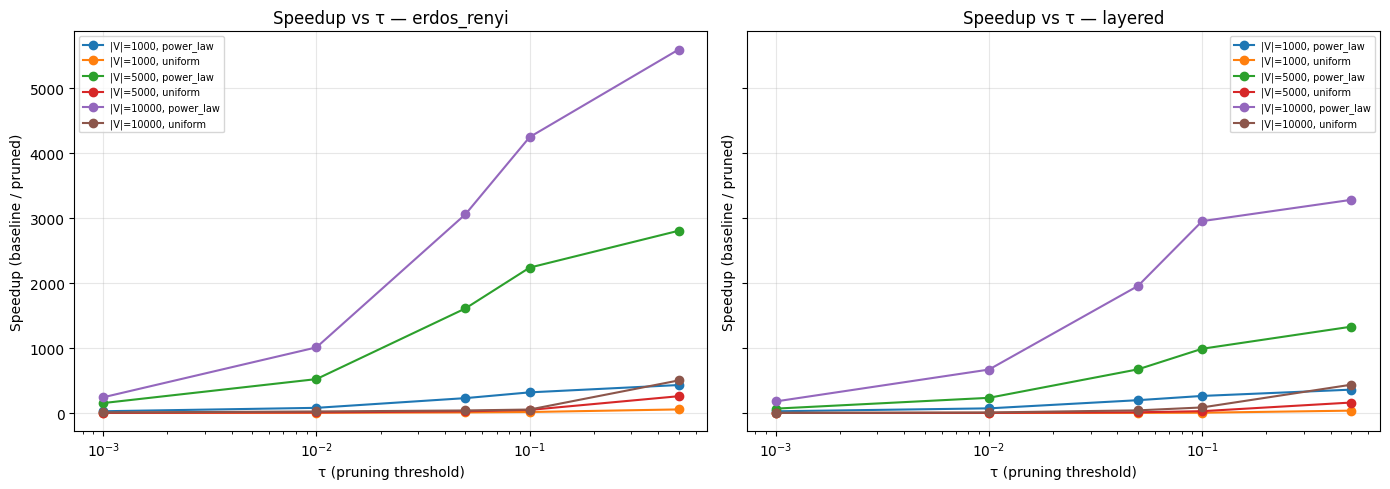

In [2]:
## ── Plot 1: Speedup vs τ ──────────────────────────────────────────────────────
# For each config (graph_type, graph_size, avg_degree, distribution, run),
# speedup = baseline_time / pruned_time

# Merge baseline timing into pruned rows
bl_time = baseline[["graph_type", "graph_size", "avg_degree", "distribution", "run",
                     "execution_time_ms"]].rename(columns={"execution_time_ms": "baseline_ms"})
merged = pruned.merge(bl_time, on=["graph_type", "graph_size", "avg_degree", "distribution", "run"])
merged["speedup"] = merged["baseline_ms"] / merged["execution_time_ms"].clip(lower=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = merged[merged["graph_type"] == gtype]
    for (n, dist), grp in sub.groupby(["graph_size", "distribution"]):
        means = grp.groupby("tau")["speedup"].mean()
        label = f"|V|={n}, {dist}"
        ax.plot(means.index, means.values, marker="o", label=label)
    ax.set_xlabel("τ (pruning threshold)")
    ax.set_ylabel("Speedup (baseline / pruned)")
    ax.set_title(f"Speedup vs τ — {gtype}")
    ax.legend(fontsize=7)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_speedup_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

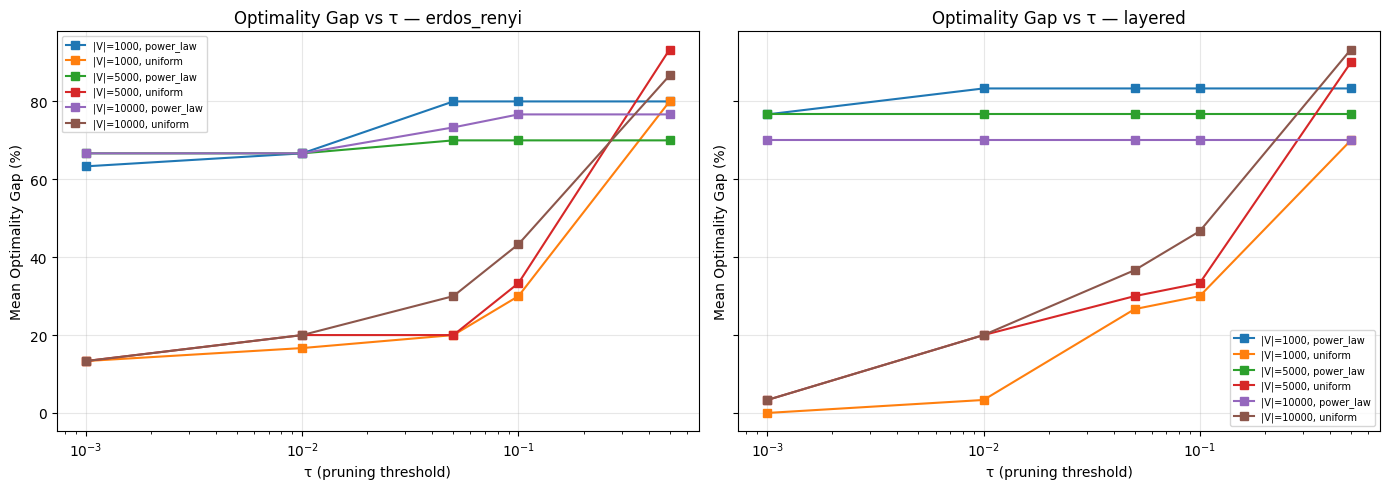

In [3]:
## ── Plot 2: Optimality Gap vs τ ───────────────────────────────────────────────
# optimality_gap_pct is already computed in experiment_results.csv
# 100 means no path found by pruned; otherwise it's the % increase in cost

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = merged[merged["graph_type"] == gtype]
    for (n, dist), grp in sub.groupby(["graph_size", "distribution"]):
        means = grp.groupby("tau")["optimality_gap_pct"].mean()
        label = f"|V|={n}, {dist}"
        ax.plot(means.index, means.values, marker="s", label=label)
    ax.set_xlabel("τ (pruning threshold)")
    ax.set_ylabel("Mean Optimality Gap (%)")
    ax.set_title(f"Optimality Gap vs τ — {gtype}")
    ax.legend(fontsize=7)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_optimality_gap_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

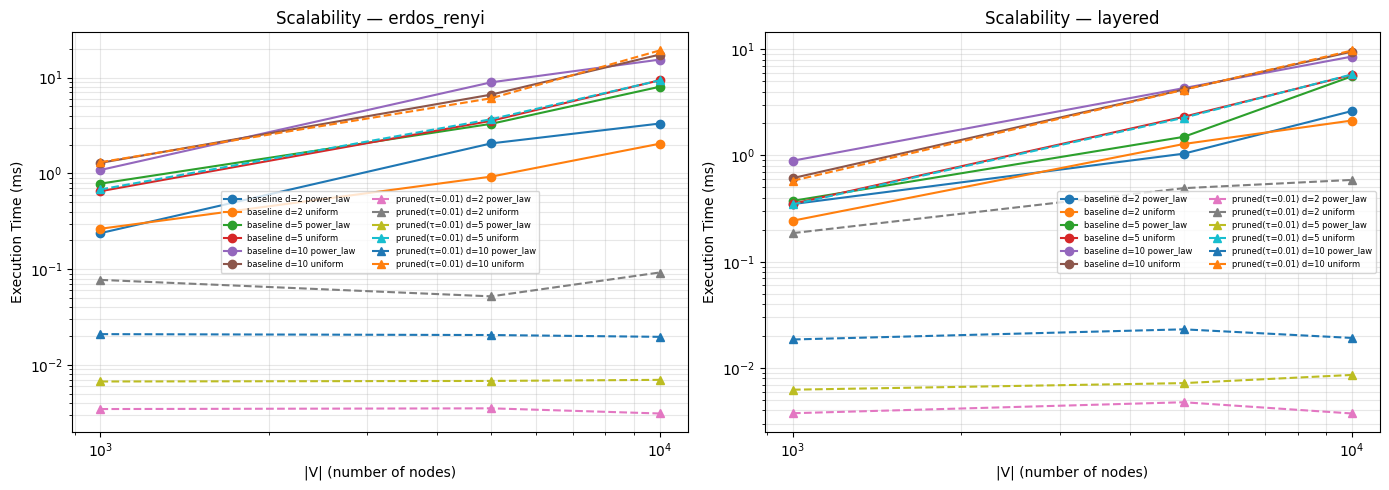

In [4]:
## ── Plot 3: Scalability — Execution Time vs |V| (log-log) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    # Baseline scalability
    bl_sub = baseline[baseline["graph_type"] == gtype]
    for (deg, dist), grp in bl_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["execution_time_ms"].mean()
        ax.plot(means.index, means.values, marker="o", linestyle="-",
                label=f"baseline d={deg} {dist}")

    # Pruned at tau=0.01
    pr_sub = pruned[(pruned["graph_type"] == gtype) & (pruned["tau"] == 0.01)]
    for (deg, dist), grp in pr_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["execution_time_ms"].mean()
        ax.plot(means.index, means.values, marker="^", linestyle="--",
                label=f"pruned(τ=0.01) d={deg} {dist}")

    ax.set_xlabel("|V| (number of nodes)")
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"Scalability — {gtype}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("plot3_scalability.png", dpi=150, bbox_inches="tight")
plt.show()

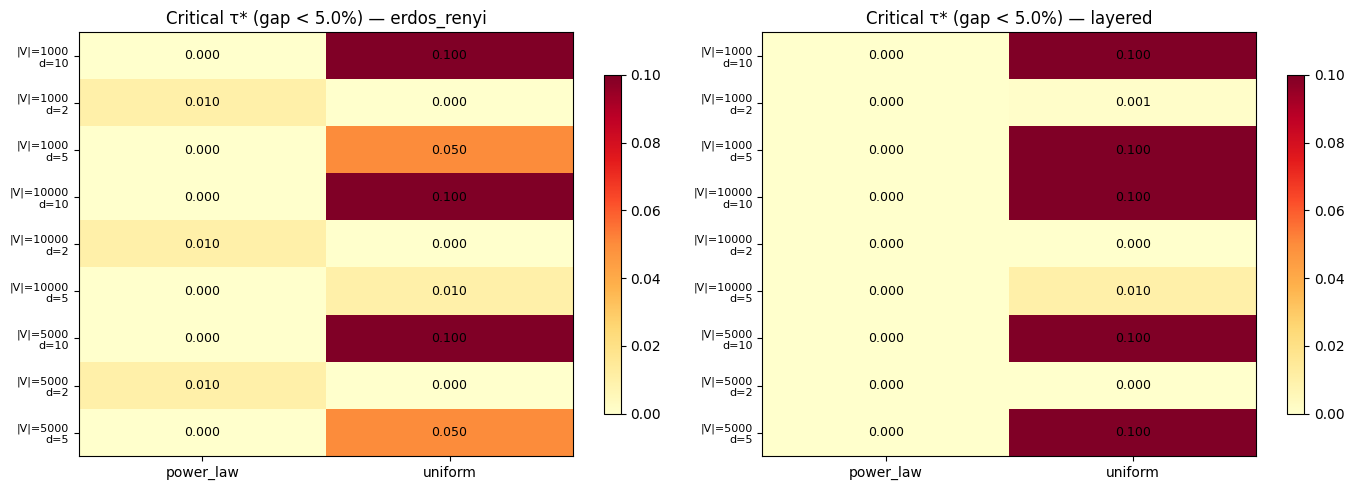

In [5]:
## ── Plot 4: Critical τ Heatmap ────────────────────────────────────────────────
# Critical τ* = largest τ where mean optimality gap < 5 % (i.e. near-optimal)
GAP_THRESHOLD = 5.0
tau_values = sorted(pruned["tau"].unique())

records = []
for (gtype, n, deg, dist), grp in pruned.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution"]):
    critical_tau = 0.0
    for tau in tau_values:
        mean_gap = grp[grp["tau"] == tau]["optimality_gap_pct"].mean()
        if mean_gap < GAP_THRESHOLD:
            critical_tau = tau
    records.append({"graph_type": gtype, "graph_size": n, "avg_degree": deg,
                     "distribution": dist, "critical_tau": critical_tau})

ct_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    sub = ct_df[ct_df["graph_type"] == gtype].copy()
    sub["config"] = sub.apply(lambda r: f"|V|={r.graph_size}\nd={r.avg_degree}", axis=1)
    pivot = sub.pivot_table(index="config", columns="distribution",
                            values="critical_tau", aggfunc="first")
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(f"Critical τ* (gap < {GAP_THRESHOLD}%) — {gtype}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("plot4_critical_tau_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

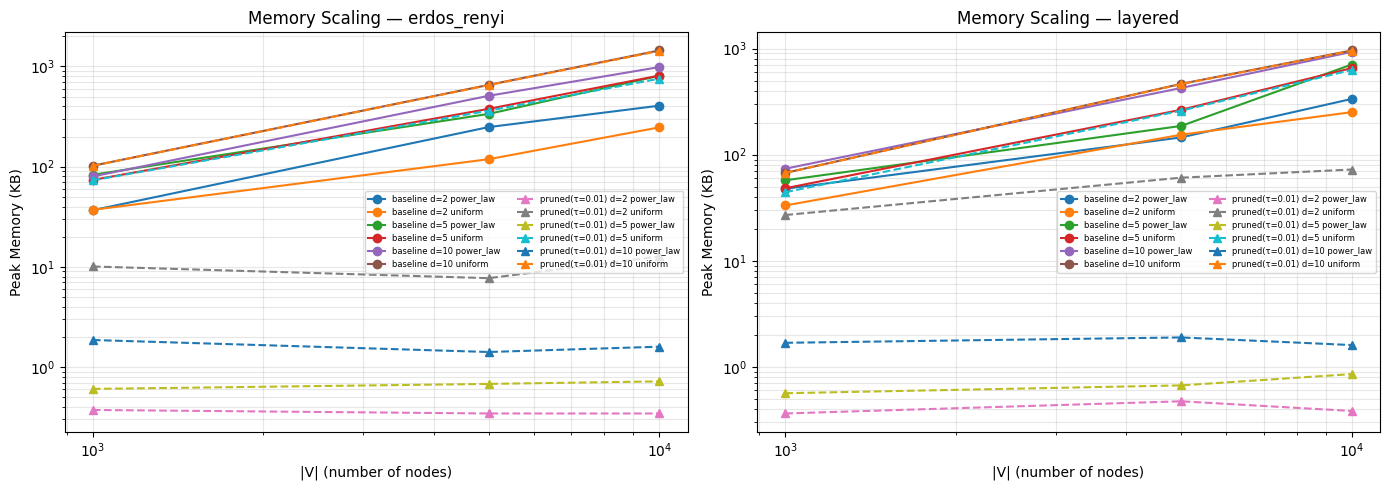

In [6]:
## ── Plot 5: Memory Scaling — Baseline vs Pruned ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gtype in zip(axes, ["erdos_renyi", "layered"]):
    # Baseline memory
    bl_sub = baseline[baseline["graph_type"] == gtype]
    for (deg, dist), grp in bl_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["peak_memory_bytes"].mean() / 1024
        ax.plot(means.index, means.values, marker="o", linestyle="-",
                label=f"baseline d={deg} {dist}")

    # Pruned at tau=0.01
    pr_sub = pruned[(pruned["graph_type"] == gtype) & (pruned["tau"] == 0.01)]
    for (deg, dist), grp in pr_sub.groupby(["avg_degree", "distribution"]):
        means = grp.groupby("graph_size")["peak_memory_bytes"].mean() / 1024
        ax.plot(means.index, means.values, marker="^", linestyle="--",
                label=f"pruned(τ=0.01) d={deg} {dist}")

    ax.set_xlabel("|V| (number of nodes)")
    ax.set_ylabel("Peak Memory (KB)")
    ax.set_title(f"Memory Scaling — {gtype}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("plot5_memory_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
## ── Plot 6: Statistical Significance — Wilcoxon Signed-Rank ──────────────────
# For each (graph_type, graph_size, avg_degree, distribution, tau), test whether
# pruned execution time differs significantly from baseline (paired by run).

results = []
for (gtype, n, deg, dist, tau), grp in merged.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution", "tau"]):
    bl_times = grp["baseline_ms"].values
    pr_times = grp["execution_time_ms"].values
    if len(bl_times) >= 5 and np.std(bl_times - pr_times) > 0:
        stat, pval = stats.wilcoxon(bl_times, pr_times, alternative="greater")
    else:
        stat, pval = np.nan, np.nan
    results.append({
        "graph_type": gtype, "graph_size": n, "avg_degree": deg,
        "distribution": dist, "tau": tau,
        "baseline_mean_ms": np.mean(bl_times),
        "pruned_mean_ms": np.mean(pr_times),
        "speedup": np.mean(bl_times) / max(np.mean(pr_times), 1e-9),
        "wilcoxon_stat": stat, "p_value": pval,
        "significant": pval < 0.05 if not np.isnan(pval) else False
    })

stat_df = pd.DataFrame(results)
sig_count = stat_df["significant"].sum()
total = len(stat_df)
print(f"Significant speedups: {sig_count}/{total} configs (p < 0.05)")
print(f"\nSummary by tau:")
print(stat_df.groupby("tau")[["speedup", "p_value", "significant"]].mean().round(4))
print(f"\nTop 10 fastest speedups:")
stat_df.sort_values("speedup", ascending=False).head(10)[
    ["graph_type", "graph_size", "avg_degree", "distribution", "tau",
     "speedup", "p_value", "significant"]]

Significant speedups: 151/180 configs (p < 0.05)

Summary by tau:
         speedup  p_value  significant
tau                                   
0.001    55.9645   0.1789       0.6667
0.010   205.4580   0.1373       0.7222
0.050   562.9601   0.0502       0.8889
0.100   850.0843   0.0123       0.9167
0.500  1186.1946   0.0010       1.0000

Top 10 fastest speedups:


,graph_type,graph_size,avg_degree,distribution,tau,speedup,p_value,significant
84,erdos_renyi,10000,10,power_law,0.50,8292.349462,0.000977,True
74,erdos_renyi,10000,5,power_law,0.50,5279.710526,0.000977,True
83,erdos_renyi,10000,10,power_law,0.10,4975.409677,0.000977,True
73,erdos_renyi,10000,5,power_law,0.10,4223.768421,0.000977,True
54,erdos_renyi,5000,10,power_law,0.50,3870.493506,0.000977,True
174,layered,10000,10,power_law,0.50,3510.958848,0.000977,True
164,layered,10000,5,power_law,0.50,3477.581250,0.000977,True
173,layered,10000,10,power_law,0.10,3358.909449,0.000977,True
82,erdos_renyi,10000,10,power_law,0.05,2882.947664,0.000977,True
53,erdos_renyi,5000,10,power_law,0.10,2874.868167,0.000977,True


In [8]:
## ── Summary: Edges Relaxed Ratio & Path-Found Rate ──────────────────────────
# Shows pruning effectiveness: what fraction of edges does the pruned variant explore?

summary_rows = []
for (gtype, n, deg, dist, tau), grp in merged.groupby(
        ["graph_type", "graph_size", "avg_degree", "distribution", "tau"]):
    bl_edges = grp["edges_relaxed"].values  # this is the pruned edges_relaxed
    bl_edges_baseline = baseline[
        (baseline["graph_type"] == gtype) & (baseline["graph_size"] == n) &
        (baseline["avg_degree"] == deg) & (baseline["distribution"] == dist)
    ]["edges_relaxed"].mean()
    path_found = (grp["path_length"] > 0).mean()
    summary_rows.append({
        "graph_type": gtype, "graph_size": n, "avg_degree": deg,
        "distribution": dist, "tau": tau,
        "edges_ratio": grp["edges_relaxed"].mean() / max(bl_edges_baseline, 1),
        "path_found_rate": path_found,
        "mean_gap": grp["optimality_gap_pct"].mean()
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Mean by τ ===")
print(summary_df.groupby("tau")[["edges_ratio", "path_found_rate", "mean_gap"]].mean().round(4))
print("\n=== Mean by graph_type and tau ===")
print(summary_df.groupby(["graph_type", "tau"])[["edges_ratio", "path_found_rate"]].mean().round(4))

=== Mean by τ ===
       edges_ratio  path_found_rate  mean_gap
tau                                          
0.001       0.4317           0.4917   38.8889
0.010       0.3645           0.4389   44.1667
0.050       0.2733           0.3667   51.3889
0.100       0.2015           0.3194   56.1111
0.500       0.0094           0.0722   80.8333

=== Mean by graph_type and tau ===
                   edges_ratio  path_found_rate
graph_type  tau                                
erdos_renyi 0.001       0.3940           0.4833
            0.010       0.3374           0.4500
            0.050       0.2584           0.3889
            0.100       0.1859           0.3222
            0.500       0.0066           0.0667
layered     0.001       0.4695           0.5000
            0.010       0.3915           0.4278
            0.050       0.2881           0.3444
            0.100       0.2170           0.3167
            0.500       0.0123           0.0778
